# French Presidential Elections Opinion Polling Analysis

This notebook downloads opinion polling data for the last 5 French presidential elections from Wikipedia and creates LOESS regression charts. Properly separates **First Round** and **Second Round** polls. Uses **Polars** for fast data processing.

**Debug Feature**: Exports CSV files for each year's polling data to `polling_data/` directory.

In [1]:
# Install required packages
import subprocess
import sys

packages = ['polars', 'pandas', 'numpy', 'matplotlib', 'scipy', 'beautifulsoup4', 'lxml', 'statsmodels']
for package in packages:
    try:
        __import__(package)
    except ImportError:
        print(f'Installing {package}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])

Installing beautifulsoup4...



[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pl.Config.set_fmt_str_lengths(100)

from polls_helpers import (
    ELECTION_DATES,
    MIN_MEAN_POLL_PCT,
    convert_dates_to_relative_days,
    create_election_chart,
    create_relative_day_charts,
    export_to_csv,
    filter_by_time_cutoff,
    get_candidate_color,
    get_first_round_candidates,
    get_loess_value_at_relative_day,
    get_second_round_matchups,
    process_year_data,
)

print('All required packages imported successfully!')

All required packages imported successfully!


## Configuration

In [3]:
ELECTION_ROUND = 'first'

TIME_CUTOFF = '1y'

print(f"Analyzing: {ELECTION_ROUND.upper()} ROUND")
print(f"Time cutoff: {TIME_CUTOFF}")
print(f"CSV debug files will be saved to: polling_data/")

Analyzing: FIRST ROUND
Time cutoff: 1y
CSV debug files will be saved to: polling_data/


## Download and Analyze Polling Data

In [4]:
# Download polling data for all 5 elections
years = [2022, 2017, 2012, 2007, 2002]
all_election_data = {}

print(f"Downloading polling data for {len(years)} elections...\n")

for year in years:
    try:
        print(f"Processing {year}...", end=' ', flush=True)
        polls_data = process_year_data(year, round_type=ELECTION_ROUND)
        
        if polls_data is not None and len(polls_data) > 0:
            all_election_data[year] = polls_data
            print(f"✓ Loaded {len(polls_data)} polls")
        else:
            print(f"✗ No data found")

    except Exception as e:
        print(f"\n  ✗ ERROR in {year}: {type(e).__name__}: {str(e)[:100]}")

print(f"\n✓ Total elections with data: {len(all_election_data)}")
if all_election_data:
    print(f"  Years: {list(all_election_data.keys())}")



Processing 2022... Fetching FIRST ROUND data for 2022...
  Removed 1 polls dated on/after 2022-04-10
  Dropped low-polling candidates (≤1.0%): Arthaud
✓ Found 548 first round polls for 2022
  📊 CSV exported: polling_data/2022_first_round_polls.csv (548 rows, 12 columns)
     Columns: date, Macron, Le Pen, Mélenchon, Zemmour...
✓ Loaded 548 polls
Processing 2017... Fetching FIRST ROUND data for 2017...
  Removed 1 polls dated on/after 2017-04-23
  Dropped low-polling candidates (≤1.0%): Asselineau, Lassalle, Arthaud
✓ Found 453 first round polls for 2017
  📊 CSV exported: polling_data/2017_first_round_polls.csv (453 rows, 9 columns)
     Columns: date, Macron, Le Pen, Fillon, Mélenchon...
✓ Loaded 453 polls
Processing 2012... Fetching FIRST ROUND data for 2012...
  Removed 1 polls dated on/after 2012-04-22
  Dropped low-polling candidates (≤1.0%): Dupont-Aignan, Poutou, Arthaud
✓ Found 374 first round polls for 2012
  📊 CSV exported: polling_data/2012_first_round_polls.csv (374 rows, 8

In [5]:
# Sanity check: imports + helpers wired up
print(f"ELECTION_DATES year keys: {sorted(ELECTION_DATES.keys(), reverse=True)}")
print(f"2022 candidates ({len(get_first_round_candidates(2022))}): {get_first_round_candidates(2022)[:5]}...")
print(f"Loaded {len(all_election_data)} elections: {sorted(all_election_data.keys(), reverse=True)}")


ELECTION_DATES year keys: [2022, 2017, 2012, 2007, 2002]
2022 candidates (12): ['Macron', 'Le Pen', 'Mélenchon', 'Zemmour', 'Pécresse']...
Loaded 5 elections: [2022, 2017, 2012, 2007, 2002]


## Generate Charts


Election 2022 - FIRST ROUND
Candidates: Macron, Le Pen, Mélenchon, Zemmour, Pécresse, Hidalgo, Jadot, Roussel, Dupont-Aignan, Arthaud, Poutou, Lassalle
Total polls: 548
Date range: 2017-04-23 to 2022-04-08


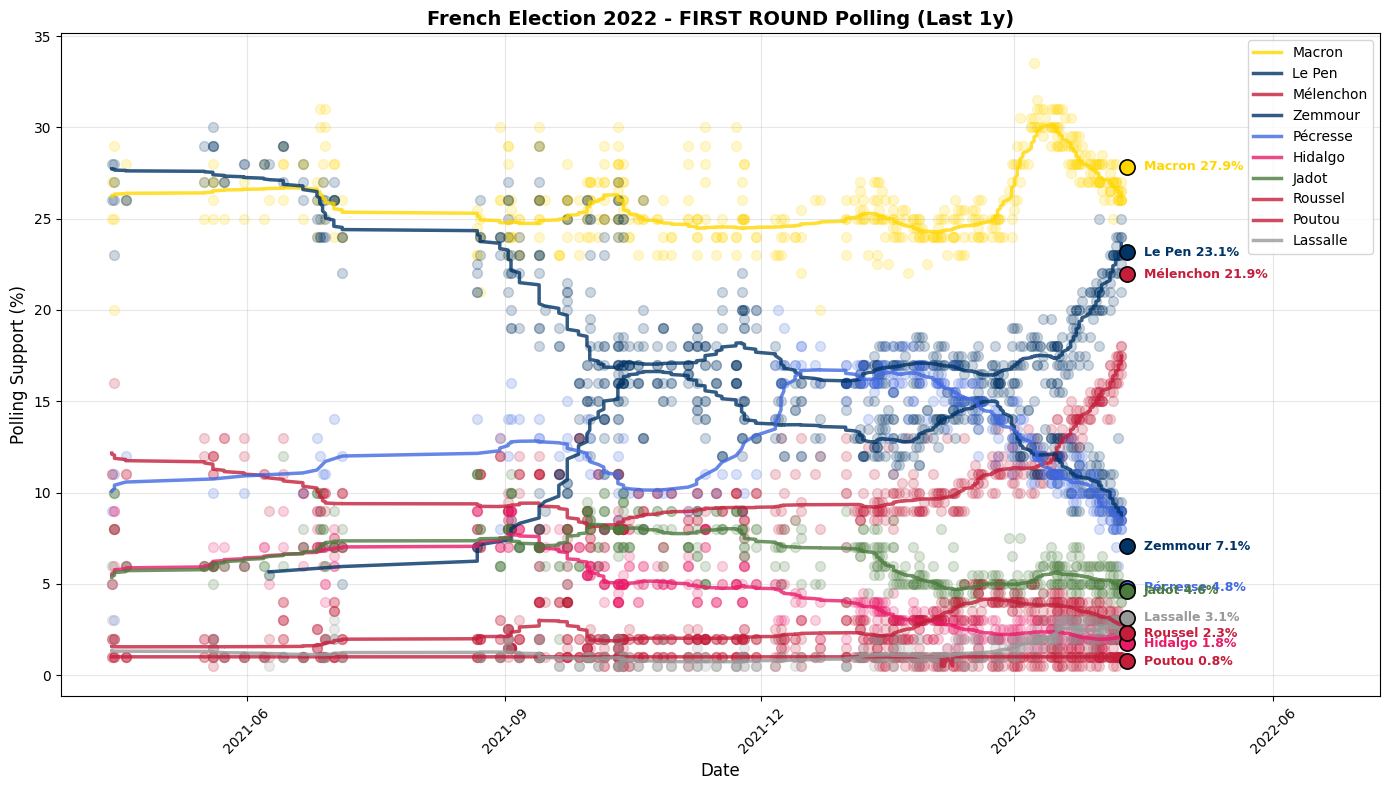

Chart created for 2022 FIRST ROUND (488 polls)

Election 2017 - FIRST ROUND
Candidates: Macron, Le Pen, Fillon, Mélenchon, Hamon, Dupont-Aignan, Asselineau, Lassalle, Arthaud, Poutou
Total polls: 453
Date range: 2012-04-22 to 2017-04-21


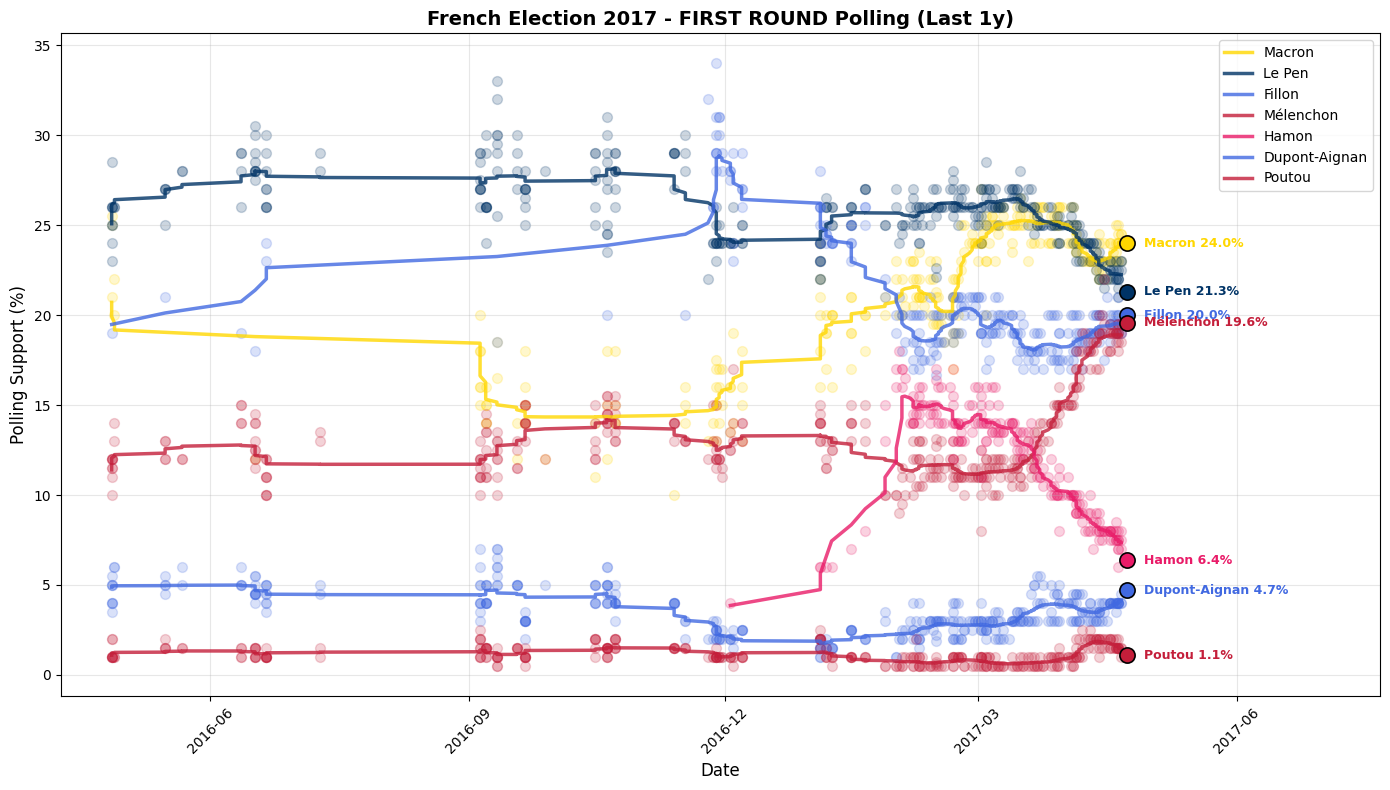

Chart created for 2017 FIRST ROUND (348 polls)

Election 2012 - FIRST ROUND
Candidates: Hollande, Sarkozy, Le Pen, Mélenchon, Bayrou, Joly, Dupont-Aignan, Poutou, Arthaud
Total polls: 374
Date range: 2007-04-22 to 2012-04-20


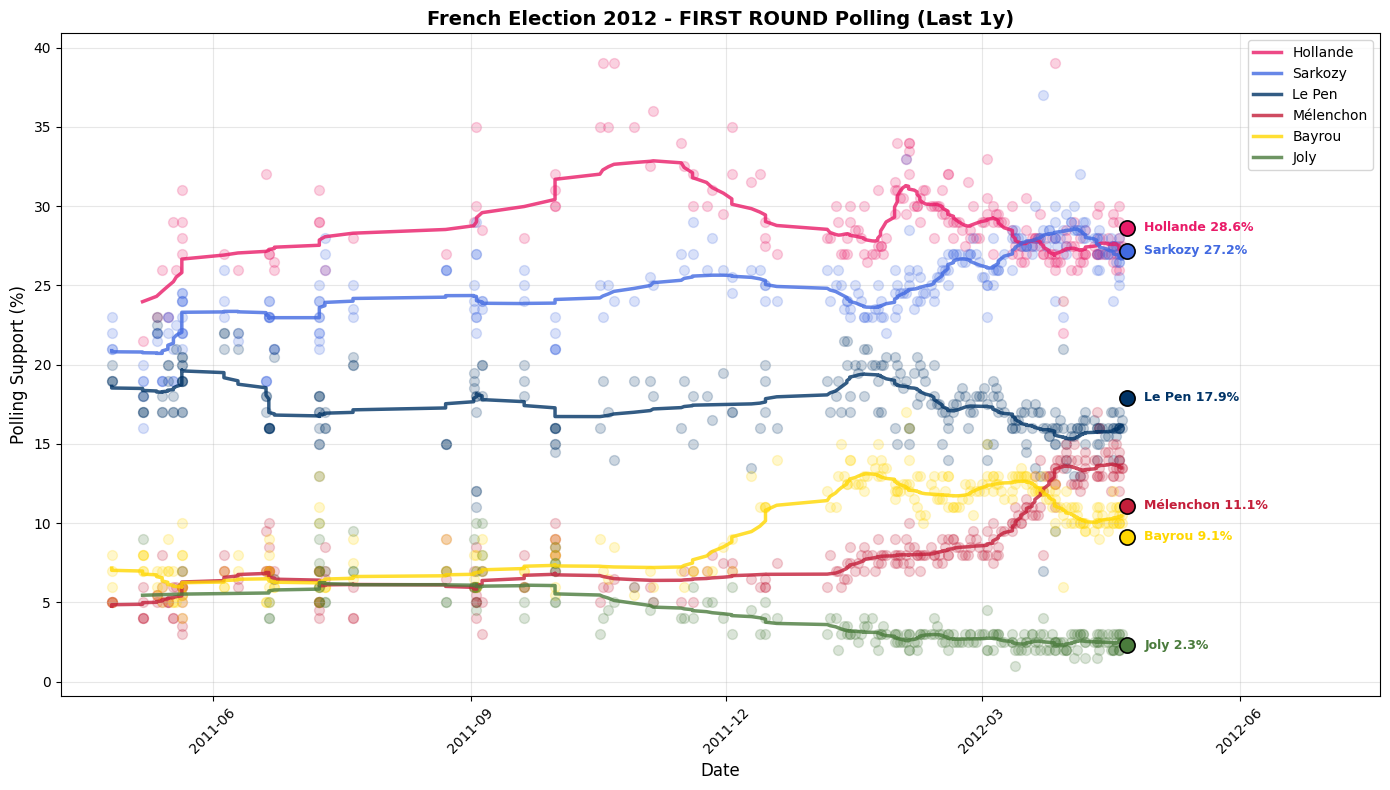

Chart created for 2012 FIRST ROUND (267 polls)

Election 2007 - FIRST ROUND
Candidates: Sarkozy, Royal, Bayrou, Le Pen, Besancenot, Villiers, Buffet, Voynet, Laguiller, Bové
Total polls: 272
Date range: 2005-02-13 to 2007-04-21


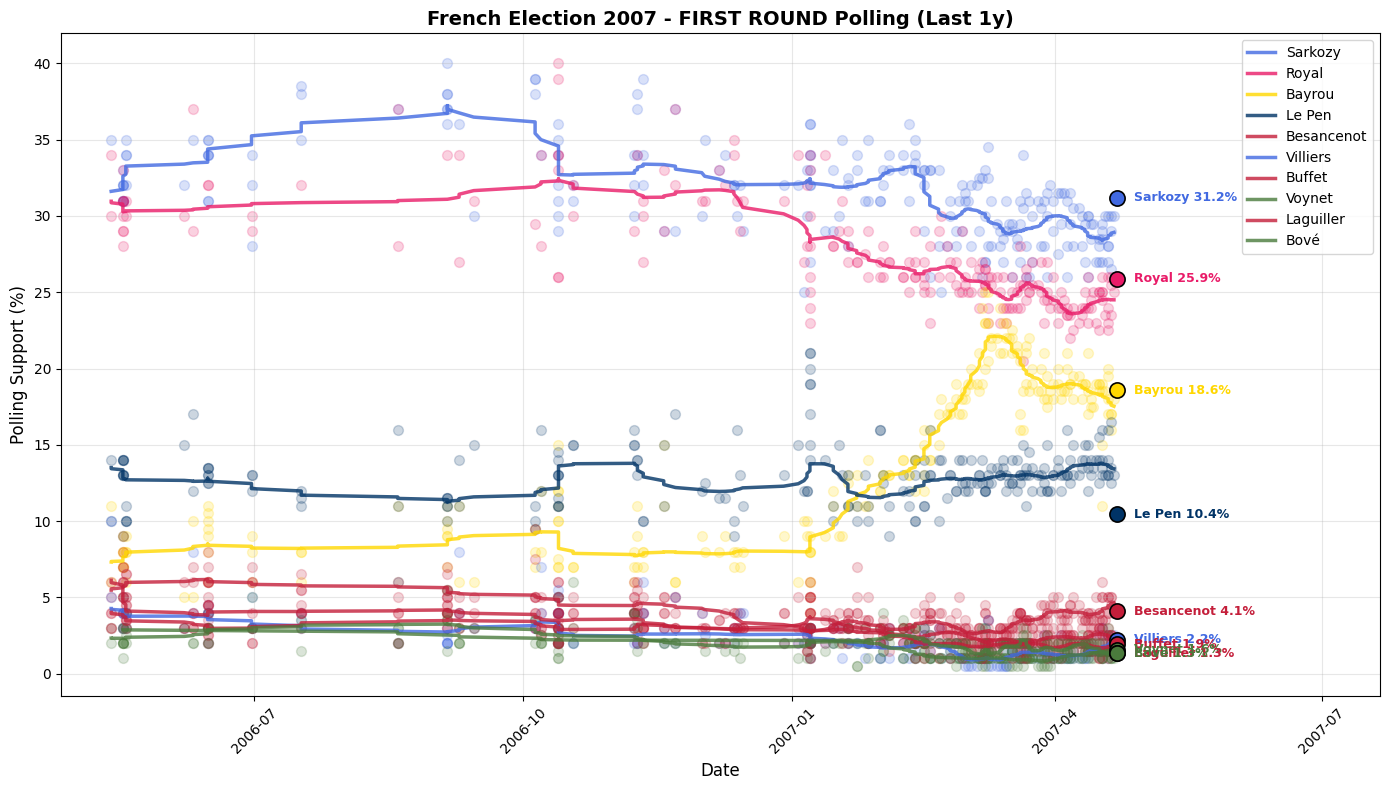

Chart created for 2007 FIRST ROUND (232 polls)

Election 2002 - FIRST ROUND
Candidates: Chirac, Jospin, Le Pen, Bayrou, Madelin, Chevènement, Mamère, Laguiller, Hue, Besancenot
Total polls: 160
Date range: 1995-04-23 to 2002-04-18


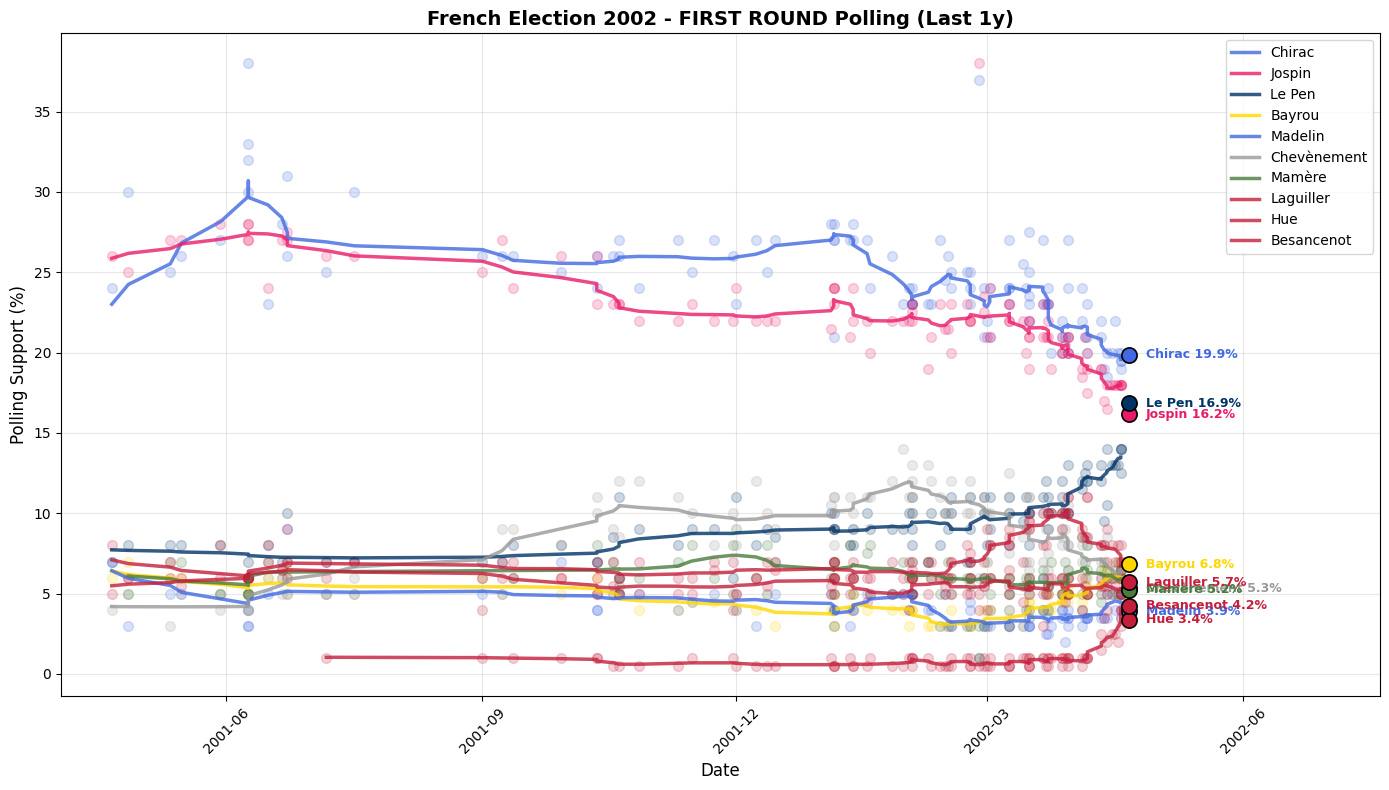

Chart created for 2002 FIRST ROUND (111 polls)


In [6]:
# Create charts for each election
for year in years:
    if year in all_election_data:
        print(f"\n{'='*60}")
        print(f"Election {year} - {ELECTION_ROUND.upper()} ROUND")
        print(f"{'='*60}")
        polls_data = all_election_data[year]
        
        if ELECTION_ROUND == 'first':
            candidates = get_first_round_candidates(year)
        else:
            matchups = get_second_round_matchups(year)
            print(f"Matchups: {', '.join([f'{c1} vs {c2}' for c1, c2 in matchups])}")
            candidates = list(set([c for m in matchups for c in m]))
        
        print(f"Candidates: {', '.join(candidates)}")
        print(f"Total polls: {polls_data.height}")
        
        if 'date' in polls_data.columns:
            date_min = polls_data['date'].min()
            date_max = polls_data['date'].max()
            print(f"Date range: {date_min} to {date_max}")
        
        # Create chart
        create_election_chart(year, polls_data.clone(), candidates, ELECTION_ROUND, TIME_CUTOFF)

## Summary Statistics

In [7]:
# Display summary statistics
for year in sorted(all_election_data.keys(), reverse=True):
    print(f"\n{'='*60}")
    print(f"Election {year} - {ELECTION_ROUND.upper()} ROUND - Summary Statistics")
    print(f"{'='*60}")
    polls_data = all_election_data[year]
    
    if TIME_CUTOFF:
        election_date = ELECTION_DATES.get(year)
        if election_date:
            polls_data = filter_by_time_cutoff(polls_data, TIME_CUTOFF, election_date)
            print(f"Filtered to {TIME_CUTOFF}: {polls_data.height} polls\n")
    
    if ELECTION_ROUND == 'first':
        candidates = get_first_round_candidates(year)
    else:
        matchups = get_second_round_matchups(year)
        candidates = list(set([c for m in matchups for c in m]))
    
    for candidate in candidates:
        if candidate in polls_data.columns:
            filtered = polls_data.filter(pl.col(candidate).is_not_null())
            if filtered.height > 0:
                data_series = filtered[candidate]
                mean_val = data_series.mean()
                min_val = data_series.min()
                max_val = data_series.max()
                std_val = data_series.std()
                print(f"\n{candidate}:")
                print(f"  Polls: {filtered.height}")
                if mean_val is not None:
                    print(f"  Mean: {mean_val:.1f}%")
                    print(f"  Min: {min_val:.1f}%")
                    print(f"  Max: {max_val:.1f}%")
                    print(f"  Std: {std_val:.1f}%")


Election 2022 - FIRST ROUND - Summary Statistics
Filtered to 1y: 488 polls


Macron:
  Polls: 488
  Mean: 26.1%
  Min: 20.0%
  Max: 33.5%
  Std: 2.2%

Le Pen:
  Polls: 488
  Mean: 19.5%
  Min: 13.0%
  Max: 30.0%
  Std: 3.7%

Mélenchon:
  Polls: 486
  Mean: 10.8%
  Min: 6.0%
  Max: 18.0%
  Std: 2.5%

Zemmour:
  Polls: 388
  Mean: 12.9%
  Min: 5.0%
  Max: 19.0%
  Std: 2.5%

Pécresse:
  Polls: 336
  Mean: 12.9%
  Min: 3.0%
  Max: 20.0%
  Std: 3.0%

Hidalgo:
  Polls: 478
  Mean: 4.1%
  Min: 1.0%
  Max: 9.0%
  Std: 2.1%

Jadot:
  Polls: 483
  Mean: 6.4%
  Min: 2.0%
  Max: 12.0%
  Std: 1.6%

Roussel:
  Polls: 484
  Mean: 2.8%
  Min: 1.0%
  Max: 5.0%
  Std: 1.0%

Poutou:
  Polls: 482
  Mean: 1.0%
  Min: 0.5%
  Max: 3.0%
  Std: 0.4%

Lassalle:
  Polls: 443
  Mean: 1.5%
  Min: 0.5%
  Max: 3.0%
  Std: 0.8%

Election 2017 - FIRST ROUND - Summary Statistics
Filtered to 1y: 348 polls


Macron:
  Polls: 279
  Mean: 21.3%
  Min: 10.0%
  Max: 27.0%
  Std: 3.9%

Le Pen:
  Polls: 348
  Mean: 25.8%
  Mi

## Polling Change Analysis - Days Until First Round

This section allows you to analyze how candidate polling support changed between two specific days relative to the first round election. For example, "days -100 to -50" shows the change from 100 days before the election to 50 days before.

**How to use**: Modify `START_DAYS` and `END_DAYS` below (negative numbers = days before election), then run this cell.


Polling Change Analysis: Day -1 to Actual Result
Data available for 5 elections



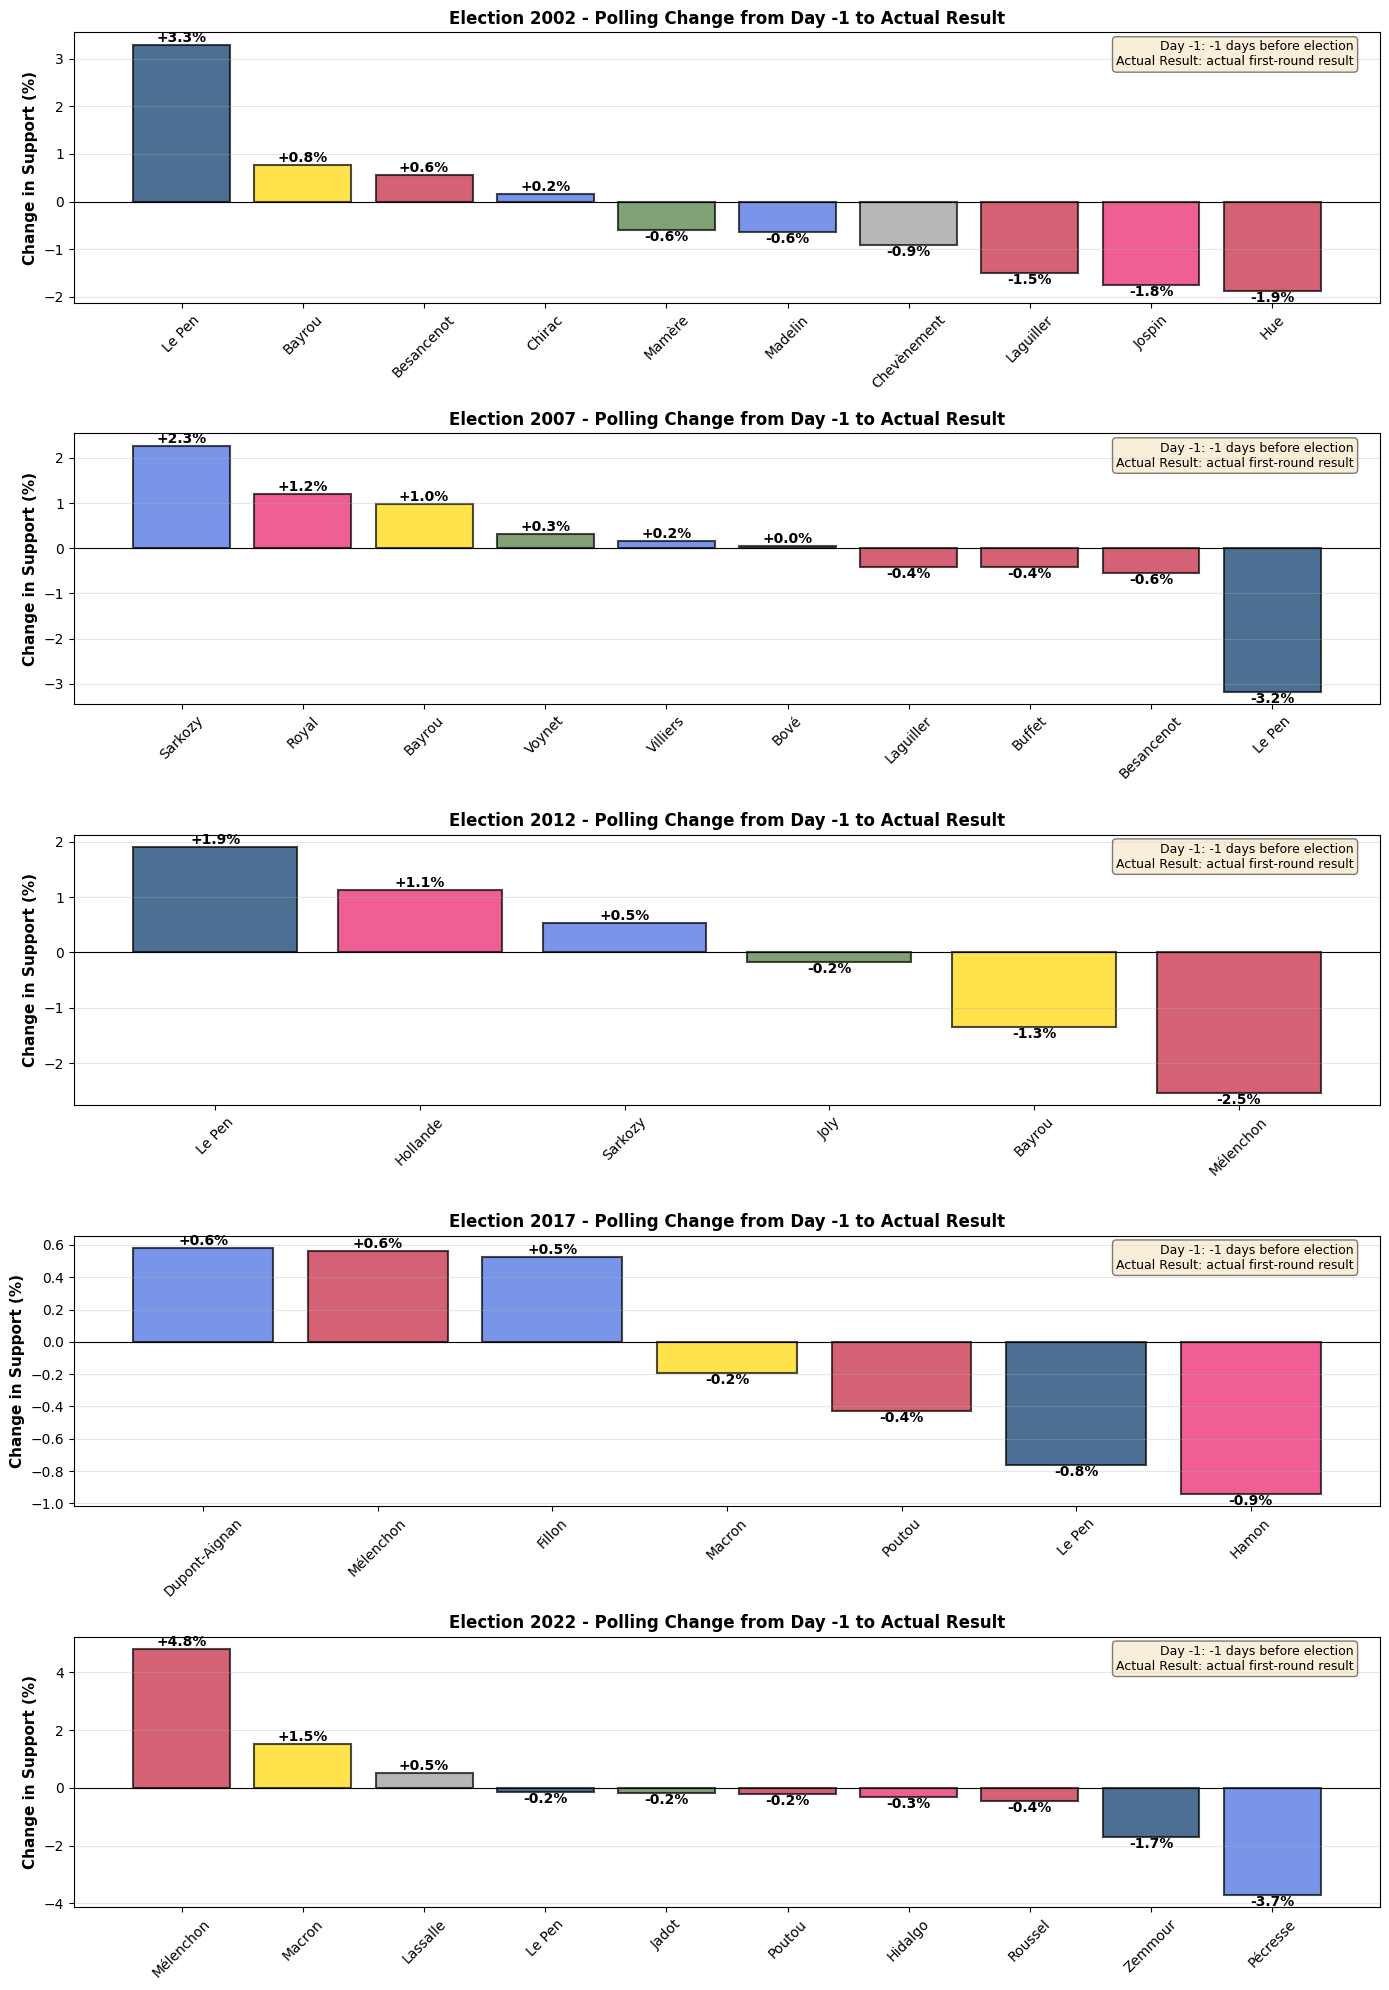

In [9]:
# Polling change analysis: how candidate support shifted between two days.
# Negative numbers = days before the election. Set END_DAYS = None to compare
# against the actual first-round result rather than a LOESS-smoothed poll value.
START_DAYS: int = -1
END_DAYS: int | None = None  # None → compare to the actual first-round result

end_label = "Actual Result" if END_DAYS is None else f"Day {END_DAYS}"
print(f"\n{'='*70}")
print(f"Polling Change Analysis: Day {START_DAYS} to {end_label}")
print(f"{'='*70}")
print(f"Data available for {len(all_election_data)} elections\n")

if all_election_data:
    create_relative_day_charts(all_election_data, START_DAYS, END_DAYS)
else:
    print("⚠️ No election data — run the download cell first.")
